# Prototype of hanoi (1)

In [1]:
import numpy as np
import math
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt


Define a function to make a variance-covariance matrix


In [2]:
def cov_mtx(var, cov):
    return squareform(cov) + np.diag(var)

## Genotype to breeding value

Define the number $L$ of loci, the number $n$ of traits, and population size $N$.

In [3]:
L = 14
n = 2
N = 10

Genotype matrix

In [4]:
G = np.zeros((L, N))
G.shape

(14, 10)

In [5]:
G

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [6]:
G.flat[np.random.choice(G.size, 20, replace = False)] = 1
G.flat[np.random.choice(G.size, 5, replace = False)] = 2

In [7]:
G

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1., 2., 0., 0., 0., 0.],
       [1., 1., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 1., 2., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [2., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 2., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 2., 1., 0., 0., 0., 0., 0.]])

In [8]:
class mut_effect:
    def __init__(self, mean: np.ndarray, var: np.ndarray, cov: np.ndarray):
        self.mean = mean
        self.var = var
        self.cov = cov
        self.n = self.mean.shape[0]
        self.L = self.mean.shape[1]
        for arr in [self.mean, self.var, self.cov]:
            if arr.ndim != 2:
                raise ValueError("mean, var, and cov should be 2D")
        if self.n != self.var.shape[0]:
            raise ValueError("mean and var should have the same number of rows (n)")
        if self.L != self.var.shape[1]:
            raise ValueError("mean and var should have the same number of columns (L)")
        if self.cov.shape[0] != math.comb(self.n, 2):
            raise ValueError("The number of rows of cov should be n choose 2")
    def show(self):
        print(f"Number of traits n:\n{self.n}")
        print(f"Number of trait pairs:\n{self.cov.shape[0]}")
        print(f"Number of loci L:\n{self.L}")
        print(f"Mutation effect of mean:\n{self.mean}")
        print(f"Mutation effect of variance:\n{self.var}")
        print(f"Mutation effect of covariance:\n{self.cov}")


Mutation effects on mean

In [9]:
M_m = np.zeros((n, L))

In [10]:
M_m[0,0:3] = 1
M_m[1,3:6] = 1

Mutation effects on variance

In [11]:
M_v = np.zeros((n, L))
M_v[0,6:9] = 1
M_v[1,9:12] = 1

Mutation effects on covariance

In [12]:
M_c = np.zeros((1, L))
M_c[0,12:15] = 1

Create mut_effect object

In [13]:
M = mut_effect(mean = M_m, var = M_v, cov = M_c)

Define breed_val class

In [14]:
class breed_val:
    def __init__(self, mean: np.ndarray, var: np.ndarray, cov: np.ndarray):
        self.mean = mean
        self.var = var 
        self.cov = cov 
        self.N = self.mean.shape[0]
        self.n = self.mean.shape[1]
        self.varcov = [cov_mtx(var = self.var[i], cov = self.cov[i]) for i in range(self.N)]
        for arr in (self.var, self.cov):
            if arr.ndim != 2:
                raise ValueError("mean, var, and cov must be 2D arrays.")
        Ns = [self.var.shape[0], self.cov.shape[0]]
        if not all(N == self.N for N in Ns):
            raise ValueError("mean, var, and cov must have the same number of rows (N)")
        if self.n != var.shape[1]:
            raise ValueError("mean and var must have the same number of columns (n)")
        if math.comb(self.n, 2) != self.cov.shape[1]:
            raise ValueError("The number of columns of cov should match the number of column of mean choose 2")
    def show(self):
        print(f"Number of traits:\n {self.n}")
        print(f"Number of trait pairs:\n {math.comb(self.n, 2)}")
        print(f"Number of individuals:\n {self.N}")
        print(f"Breeding value of mean:\n {self.mean}")
        print(f"Breeding value of variance:\n {self.var}")
        print(f"Breeding value of covariance:\n {self.cov}")
        print(f"Covariance matrices of breeding values :\n {self.varcov}")

Create breed_val object

Define a function to compute breeding value based on mut_effect and genotype

In [15]:
def comp_breed_val(mut_effect: mut_effect, genotype: np.ndarray):
    A_m = (1/2 * mut_effect.mean @ genotype).transpose()
    A_v = (1/2 * mut_effect.var @ genotype).transpose()
    A_c = (1/2 * mut_effect.cov @ genotype).transpose()
    return breed_val(mean = A_m, var = A_v, cov = A_c)

In [16]:
A = comp_breed_val(mut_effect = M, genotype = G)

In [17]:
A.mean[0:10]

array([[0. , 0.5],
       [0. , 0.5],
       [0. , 0.5],
       [0. , 0. ],
       [0.5, 1. ],
       [0. , 1. ],
       [0. , 0. ],
       [1. , 0. ],
       [0.5, 0. ],
       [0. , 0. ]])

In [18]:
M.show()

Number of traits n:
2
Number of trait pairs:
1
Number of loci L:
14
Mutation effect of mean:
[[1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Mutation effect of variance:
[[0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0.]]
Mutation effect of covariance:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.]]


## Breeding value to phenotype

In [19]:
A.N

10

In [20]:
def sim_pheno(breed_val: breed_val, mean_0, cov_0):
    z = np.zeros((A.N, A.n))
    for i in range(A.N):
        z[i] = np.random.multivariate_normal(mean = mean_0 + A.mean[i], cov = cov_0 + A.varcov[i])
    return z

In [21]:
z = sim_pheno(A, mean_0 = np.array([1,1]), cov_0 = np.array([[1,0], [0, 1]]))

In [22]:
z

array([[ 1.04192762e+00,  2.41303150e+00],
       [ 2.64151856e+00, -5.57611139e-01],
       [ 6.35073996e-01,  2.76138473e+00],
       [ 2.22491703e-03,  2.22491703e-03],
       [ 9.83605698e-01,  3.12029347e+00],
       [ 2.02909744e+00,  2.42694549e+00],
       [ 2.48384695e-01,  8.91781493e-01],
       [ 2.09149016e+00,  3.14070417e-01],
       [ 1.66076160e+00,  1.47249173e+00],
       [ 1.10948892e+00,  1.84630718e+00]])

In [23]:
A.mean

array([[0. , 0.5],
       [0. , 0.5],
       [0. , 0.5],
       [0. , 0. ],
       [0.5, 1. ],
       [0. , 1. ],
       [0. , 0. ],
       [1. , 0. ],
       [0.5, 0. ],
       [0. , 0. ]])

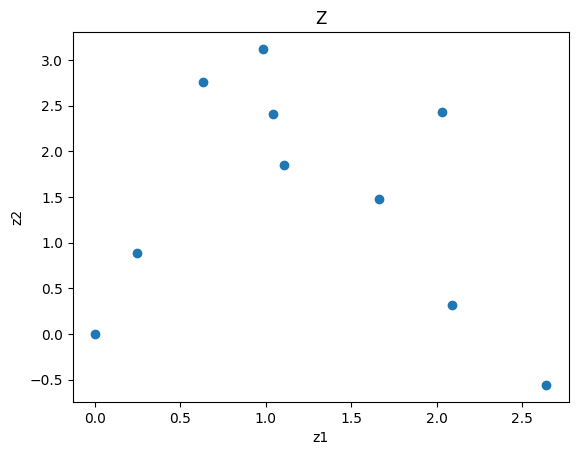

In [24]:
plt.scatter(z[:, 0], z[:, 1])
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Z")
plt.show()

## Phenotype to fitness

In [25]:
def fit_neutral(z):
    return np.repeat(np.array(1.0), len(z))

In [26]:
fit_neutral(np.array([0,0]))

array([1., 1.])

### Gaussian

In [27]:
def fit_gaus(sigma, z_opt, z):
    return np.array([np.exp(-(np.linalg.norm(z_i - z_opt))**2/(2 * sigma**2)) for z_i in z])

In [28]:
fit_gaus(1, np.array([0,0]), np.array([np.sqrt(2)/2,np.sqrt(2)/2]))

array([0.60653066, 0.60653066])

In [29]:
fit_gaus(1, np.array([0,0]), z)

array([0.03161362, 0.02614035, 0.01805591, 0.99999505, 0.00473935,
       0.0067134 , 0.65149563, 0.10683329, 0.08516366, 0.09828263])

### Multimodal

In [30]:
def fit_multimodal(sigma, p, z_opt, z):
    w = np.zeros(len(z))
    # Loop over peaks
    for i in range(len(sigma)):
        w += p[i] * fit_gaus(sigma[i], z_opt[i], z)
    return w

In [31]:
fit_multimodal(sigma = np.array([1,1]), p = np.array([0.1, 0.9]), z_opt = np.array([[0,0], [1,1]]), z = z)

array([0.3345152 , 0.07216272, 0.18030248, 0.43256594, 0.09552727,
       0.19215209, 0.73972017, 0.40276481, 0.65559485, 0.6351604 ])

In [32]:
z

array([[ 1.04192762e+00,  2.41303150e+00],
       [ 2.64151856e+00, -5.57611139e-01],
       [ 6.35073996e-01,  2.76138473e+00],
       [ 2.22491703e-03,  2.22491703e-03],
       [ 9.83605698e-01,  3.12029347e+00],
       [ 2.02909744e+00,  2.42694549e+00],
       [ 2.48384695e-01,  8.91781493e-01],
       [ 2.09149016e+00,  3.14070417e-01],
       [ 1.66076160e+00,  1.47249173e+00],
       [ 1.10948892e+00,  1.84630718e+00]])

In [33]:
x = np.linspace(0, 3, 100)
y = np.linspace(0, 3, 100)
z1,z2 = np.meshgrid(x, y)

z = np.column_stack([z1.ravel(), z2.ravel()])

In [34]:
w = fit_multimodal(sigma = np.array([0.5, 0.5]), p = np.array([1, 1]), z_opt = np.array([[1,2], [2,1]]), z = z)
w_grid = w.reshape(z1.shape)

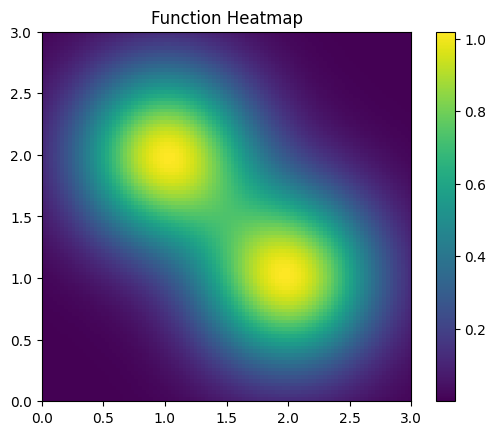

In [35]:
plt.imshow(w_grid, extent=[0, 3, 0, 3], origin='lower', cmap='viridis')
plt.colorbar()
plt.title('Function Heatmap')
plt.show()

### Step function

In [36]:
def fit_step(boxes, z):
    """
    z:     (N, n) array of n-dimensional phenotypes of N individuals.
    boxes: (m, 2, n) array of m boxes, where boxes[i, 0] = lower bounds, boxes[i, 1] = upper bounds. Fitness of phenotype within boxes is 1.
    Returns: (N,) array of 0 or 1
    """
    return np.astype(np.any(np.all((z[:, None, :] >= boxes[:, 0, :]) & (z[:, None, :] <= boxes[:, 1, :]), axis=2), axis =1), float)

In [37]:
ranges = np.array([
    [[1, 1], [np.inf, np.inf]]
])
x = np.array([[0,0],
              [2,0],
              [0,2],
              [2,2]])

In [38]:
boxes = np.array([
    [[-np.inf, -np.inf], [-1, -1]],
    [[1, 1], [np.inf, np.inf]]
])
boxes

array([[[-inf, -inf],
        [ -1.,  -1.]],

       [[  1.,   1.],
        [ inf,  inf]]])

In [39]:
z = np.array([
    [-2, -2],
    [-2, 0],
    [-2, 2],
    [0, -2],
    [0, 0],
    [0, 2],
    [2, -2],
    [2, 0],
    [2, 2]
             ])

In [40]:
z

array([[-2, -2],
       [-2,  0],
       [-2,  2],
       [ 0, -2],
       [ 0,  0],
       [ 0,  2],
       [ 2, -2],
       [ 2,  0],
       [ 2,  2]])

In [41]:
fit_step(boxes = boxes, z = z)

array([1., 0., 0., 0., 0., 0., 0., 0., 1.])

## Selection and reproduction

In [42]:
G[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [43]:
z = sim_pheno(A, mean_0 = np.array([1,1]), cov_0 = np.array([[1,0], [0, 1]]))

In [44]:
z

array([[ 1.85647564,  3.51552432],
       [ 0.7615424 ,  0.46321705],
       [ 1.04516806,  1.46622448],
       [ 0.5588016 ,  0.5588016 ],
       [ 1.5416354 , -0.20333142],
       [ 2.45068518,  2.42785183],
       [ 1.06060817,  0.28180886],
       [ 2.94026872,  0.3599542 ],
       [ 0.90776622,  0.0120853 ],
       [-0.07110639,  1.41006912]])

In [45]:
w = fit_gaus(sigma = 1, z_opt = np.array([0,0]), z = z)

In [46]:
w

array([3.69741472e-04, 6.72160296e-01, 1.97682068e-01, 7.31791801e-01,
       2.98498106e-01, 2.60542054e-03, 5.47631334e-01, 1.24333416e-02,
       6.62262826e-01, 3.69104484e-01])

In [47]:
def sim_reproduction(popsize, genotype, fitness):
    sam = np.repeat(range(popsize), np.random.multinomial(n = 2 * popsize, pvals = fitness/sum(fitness)))
    np.random.shuffle(sam)
    return np.array([np.sum(np.random.binomial(1, genotype[:, sam[[2 * i, 2 * i + 1]]]/2), axis = 1) for i in range(popsize)]).transpose()

In [48]:
sim_reproduction(popsize = 10, genotype = np.zeros((10, 10)), fitness = np.repeat(1, 10))

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

## Mutation

In [49]:
mu = 1

In [50]:
G_next = G

In [51]:
G_next

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1., 2., 0., 0., 0., 0.],
       [1., 1., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 1., 2., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [2., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 2., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 2., 1., 0., 0., 0., 0., 0.]])

In [52]:
n_sites_genotype = np.array([(G_next == i).sum() for i in range(3)])
n_sites_genotype

array([117,  18,   5])

In [53]:
idx_sites_genotype = {i : np.where(G_next == i) for i in range(3)}

In [54]:
idx_sites_genotype

{0: (array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,
          3,  3,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  6,
          6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  8,
          8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,
          9, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11,
         12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13]),
  array([0, 1, 2, 3, 4, 5, 6, 8, 9, 0, 1, 2, 3, 5, 6, 9, 0, 1, 2, 3, 4, 5,
         6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 3, 6, 7, 8, 9, 2,
         3, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 2, 3, 6, 7, 8,
         9, 0, 1, 2, 3, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 2,
         3, 4, 5, 7, 8, 9, 1, 2, 3, 5, 6, 7, 8, 9, 1, 2, 3, 4, 5, 7, 8, 9,
         1, 2, 5, 6, 7, 8, 9])),
 1: (array([ 0,  1,  1,  1,  4,  4,  5,  5,  5,  7,  7, 

In [55]:
transition_matrix = np.array([[(1 - mu)**2, 2 * mu * (1 - mu), mu**2],
                              [mu * (1 - mu), (1 - mu)**2 + mu**2, mu * (1 - mu)],
                              [mu**2, 2 * mu * (1 - mu), (1 - mu)**2]])

In [56]:
n_sites_muts = np.array([np.random.multinomial(n_sites_genotype[i], transition_matrix[i]) for i in range(3)])

In [57]:
n_sites_muts

array([[  0,   0, 117],
       [  0,  18,   0],
       [  5,   0,   0]])

In [58]:
for i in range(3):
    geno_muts = np.repeat([0,1,2], n_sites_muts[i])
    np.random.shuffle(geno_muts)
    G_next[idx_sites_genotype[i]] = geno_muts

In [59]:
(G_next==1).sum()

np.int64(18)

In [60]:
57 + 16 + 2

75

In [61]:
def sim_mutation(genotype, mut_rate):
    # Compute transition matrix
    transition_matrix = np.array([[(1 - mut_rate)**2, 2 * mut_rate * (1 - mut_rate), mut_rate**2],
                                  [mut_rate * (1 - mut_rate), (1 - mut_rate)**2 + mut_rate**2, mut_rate * (1 - mut_rate)],
                                  [mut_rate**2, 2 * mut_rate * (1 - mut_rate), (1 - mut_rate)**2]])

    # Count the number of entries in the genotype matrix for each of the 3 genotypes
    n_sites_genotype = np.array([(genotype == i).sum() for i in range(3)])
    # Make mapping of genotype to a set of index of the genotype matrix
    idx_sites_genotype = {i : np.where(genotype == i) for i in range(3)}
    # Make realised transition count matrix, where (i, j) has number of sites with genotype i which mutate into j
    n_sites_muts = np.array([np.random.multinomial(n_sites_genotype[i], transition_matrix[i]) for i in range(3)])
    # Introduce mutations
    for i in range(3):
        geno_muts = np.repeat([0,1,2], n_sites_muts[i])
        np.random.shuffle(geno_muts)
        genotype[idx_sites_genotype[i]] = geno_muts
    # Return mutated genotype matrix
    return genotype

In [62]:
G_next_mut = sim_mutation(G_next, mut_rate = 0)

In [63]:
G_next_mut

array([[2., 2., 2., 2., 2., 2., 2., 1., 2., 2.],
       [2., 2., 2., 2., 1., 2., 2., 1., 1., 2.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [2., 2., 1., 2., 1., 0., 2., 2., 2., 2.],
       [1., 1., 2., 2., 1., 2., 2., 2., 2., 2.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [1., 2., 2., 2., 1., 0., 2., 2., 2., 2.],
       [2., 2., 2., 2., 1., 2., 2., 2., 2., 2.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [0., 2., 2., 2., 2., 2., 1., 2., 2., 2.],
       [1., 2., 2., 2., 0., 2., 2., 2., 2., 2.],
       [1., 2., 2., 2., 2., 2., 1., 2., 2., 2.],
       [1., 2., 2., 0., 1., 2., 2., 2., 2., 2.]])

## Simulate a generation without mutational effect

Mutation effect

In [97]:
L = 14
N = 9
n = 2

In [98]:
M_m = np.zeros((n, L))
M_v = np.zeros((n, L))
M_c = np.zeros((math.comb(n, 2), L))

Create mut_effect object

In [99]:
M = mut_effect(mean = M_m, var = M_v, cov = M_c)

In [100]:
M.mean[0, 0:3] = 1
M.mean[1, 3:6] = 1
#M.var[0, 6:9] = 1
#M.var[1, 9:12] = 1
#M.cov[0, 12:14] = 1

In [101]:
M.show()

Number of traits n:
2
Number of trait pairs:
1
Number of loci L:
14
Mutation effect of mean:
[[1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Mutation effect of variance:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Mutation effect of covariance:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


Initial genotype matrix.

In [108]:
G = np.zeros((101, L, N))
G.shape

(101, 14, 9)

In [109]:
G[0].flat[np.random.choice(G[0].size, 10, replace = False)] = 1

In [110]:
def sim_generation(mut_effect, genotype, mut_rate, fit_func, **kwargs):
    popsize = genotype.shape[1]
    # Breeding value
    A = comp_breed_val(mut_effect=mut_effect, genotype=genotype)
    
    # Phenotype
    z = sim_pheno(breed_val=A, mean_0=np.array([0, 0]), cov_0 = np.array([[1,0], [0,1]]))
    
    # Phenotype to fitness
    if fit_func == "fit_gaus":
        # Extract sigma and z_opt from kwargs
        sigma = kwargs.get('sigma')
        z_opt = kwargs.get('z_opt')
        w = fit_gaus(sigma=sigma, z_opt=z_opt, z=z)
    if fit_func == "fit_multimodal":
        w = fit_multimodal(sigma=sigma, p=kwargs.get('p'), z_opt=z_opt, z=z)
    if fit_func == "fit_neutral":
        w = fit_neutral(z = z)
    if fit_func == "fit_step":
        boxes = kwargs.get('boxes')
        w = fit_step(z=z, boxes=boxes)
    
    # Reproduction
    genotype_next = sim_reproduction(popsize = popsize, 
                                     genotype = genotype, 
                                     fitness = w)
    genotype_next = sim_mutation(genotype = genotype_next, 
                                 mut_rate = mut_rate)
    
    return genotype_next, z

In [111]:
G.shape

(101, 14, 9)

In [112]:
M.show()

Number of traits n:
2
Number of trait pairs:
1
Number of loci L:
14
Mutation effect of mean:
[[1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Mutation effect of variance:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Mutation effect of covariance:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [113]:
sim_generation(mut_effect = M, genotype = G[0], mut_rate = 0.001, fit_func = "fit_neutral")

ValueError: operands could not be broadcast together with shape (9,) (10,)

In [114]:
w.size

10

In [88]:
sim_generation(mut_effect = M, genotype = G[0], mut_rate = 0.001, fit_func = "fit_neutral" )

(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 2, 1, 1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 1, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]]),
 array([[ 0.87173351,  1.73789543],
        [ 0.15227044, -0.50978958],
        [-0.36652695,  1.67922217],
        [ 0.79388111,  0.79388111],
        [-0.06513811,  2.09240129],
        [ 2.60539648,  0.29049304],
        [ 0.21066429,  0.28136934],
        [-0.4831686 ,  0.6461691 ],
        [-0.14772706,  0.54337487],
        [-1.0359647 ,  1.62200294]]))

In [89]:
sim_generation(mut_effect = M, genotype = G[0], mut_rate = 0.001, fit_func = "fit_step", boxes = np.array([[[0,0],[np.inf, np.inf]]]))

(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 2, 1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0, 1, 1]]),
 array([[-0.35844081, -1.0140609 ],
        [-1.02693212,  0.44210537],
        [-0.70787058,  0.30519377],
        [ 0.32219119,  0.32219119],
        [-3.74626841,  2.60915489],
        [-0.12539804,  0.78636363],
        [-1.28738112,  0.5200068 ],
        [ 0.75245801, -0.03247231],
        [-0.94920658,  0.79553587],
        [ 1.41616883,  0.287645  ]]))

In [90]:
sim_generation(mut_effect = M, 
               genotype = G[0], 
               mut_rate = 0.001, 
               fit_func = "fit_gaus", 
               sigma = 1,
               z_opt = np.array([0, 0])
              )

(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 1, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 1]]),
 array([[-1.81699346, -1.3913718 ],
        [ 1.33721479,  0.37532091],
        [-0.56793732, -1.43442325],
        [-0.07370628, -0.07370628],
        [-2.10983529,  1.16447159],
        [ 1.91212159,  1.15876497],
        [ 0.96216531, -0.17356748],
        [ 1.66957071,  0.78586693],
        [ 2.25966905, -0.32120592],
        [-0.68560422,  0.52198484]]))

In [91]:
G.shape

(101, 14, 10)

In [80]:
G[0]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [81]:
z = np.zeros([101, N, n])
z[0]

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [92]:
for i in range(100):
    G[i+1], z[i] = sim_generation(mut_effect = M, genotype = G[i], mut_rate = 0.000, fit_func = "fit_gaus", sigma = 1, z_opt = np.array([0,0]))

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

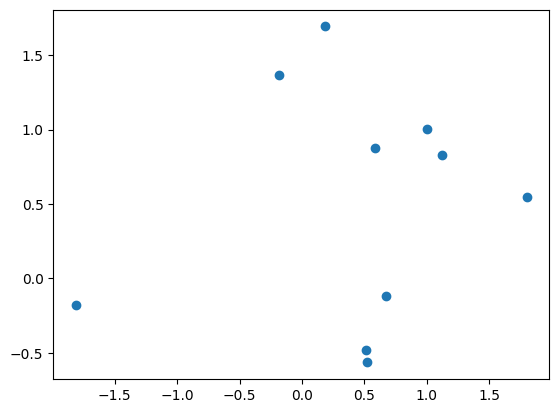

In [93]:
plt.scatter(x = z[0, :,0], y = z[0, :,1])
plt.show()

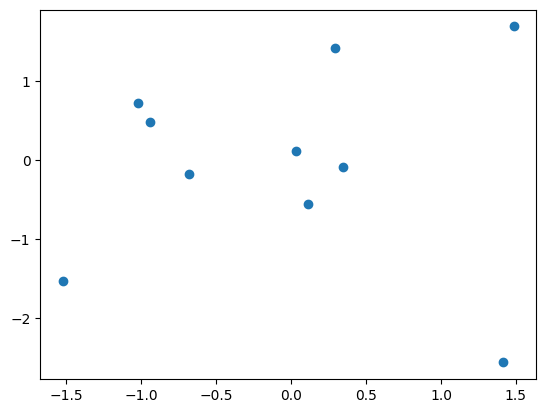

In [94]:
plt.scatter(x = z[99, :,0], y = z[99, :,1])
plt.show()

In [569]:
G[499][0:30,:]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [2., 2., 2., ..., 2., 2., 2.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [520]:
G[0].sum(axis=0)

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [521]:
G[10].sum(axis = 0)

array([6., 4., 3., 2., 2., 2., 4., 5., 3., 4., 3., 6., 2., 3., 3., 2., 4.,
       3., 4., 3., 4., 5., 3., 3., 4., 3., 4., 3., 4., 2., 2., 2., 4., 3.,
       4., 5., 3., 2., 3., 2., 4., 2., 2., 2., 4., 3., 6., 3., 3., 2., 6.,
       3., 2., 2., 3., 3., 3., 6., 3., 3., 2., 4., 2., 8., 3., 3., 2., 5.,
       2., 4., 4., 5., 4., 3., 2., 3., 4., 3., 4., 4., 3., 4., 3., 2., 5.,
       5., 5., 3., 3., 2., 4., 3., 3., 2., 4., 4., 2., 3., 3., 3.])

In [523]:
G[99].sum(axis=0)

array([24., 25., 23., 25., 23., 23., 21., 24., 23., 22., 25., 21., 22.,
       21., 24., 25., 26., 23., 25., 25., 25., 22., 22., 21., 27., 25.,
       23., 22., 24., 23., 20., 23., 22., 24., 24., 21., 24., 26., 23.,
       24., 20., 23., 23., 23., 23., 25., 24., 23., 24., 20., 24., 25.,
       22., 22., 24., 21., 23., 22., 24., 23., 22., 23., 25., 24., 24.,
       25., 20., 22., 22., 22., 21., 23., 24., 22., 24., 24., 22., 22.,
       27., 27., 24., 24., 22., 23., 22., 23., 23., 24., 22., 24., 21.,
       23., 25., 23., 22., 23., 24., 22., 24., 23.])

In [474]:
sim_generation(mut_effect = M, genotype = G0, mut_rate = 0, fit_func = "fit_gaus", sigma = 1, z_opt = np.array([3,3]))

(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[ 0.61729833,  1.08382926],
        [ 1.23518605,  2.16069499],
        [ 0.17629734, -0.32171847],
        [ 0.32451252, -1.35974173],
        [-0.70644259,  0.88309118],
        [-0.39457404,  0.27022658],
        [ 2.52212761,  1.68641015],
        [ 0.21701097,  1.84552043],
        [ 0.89303499,  1.0484944 ],
        [ 1.19152604,  0.90798297]]))

In [398]:
popsize = G0.shape[1]
popsize

10

In [418]:
A = comp_breed_val(mut_effect=M, genotype=G0)
A.show()

Number of traits:
 2
Number of trait pairs:
 1
Number of individuals:
 10
Breeding value of mean:
 [[1.  1. ]
 [0.5 0.5]
 [0.5 0. ]
 [1.  0. ]
 [0.  0. ]
 [0.  0.5]
 [0.5 0. ]
 [0.  1. ]
 [0.5 1.5]
 [0.  1. ]]
Breeding value of variance:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
Breeding value of covariance:
 [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
Covariance matrices of breeding values :
 [array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]]), array([[0., 0.],
       [0., 0.]])]


In [460]:
z = sim_pheno(breed_val=A, mean_0=np.array([0, 0]), cov_0 = np.array([[1,0], [0,1]]))
z

array([[ 0.35895423,  3.09416637],
       [ 0.57616401,  3.01928168],
       [-0.0633996 ,  1.57181284],
       [ 0.71195895,  0.19099711],
       [ 0.50814323,  1.61002076],
       [ 0.67994704,  0.73741995],
       [ 0.68077617,  0.78448404],
       [ 0.47577012,  1.54700672],
       [ 1.83253773,  0.68473585],
       [-0.45893072,  0.31054476]])

In [461]:
w = fit_gaus(sigma=1, z_opt=np.array([3,3]), z=z)
w

array([3.04400825e-02, 5.29887130e-02, 3.30582956e-03, 1.41190623e-03,
       1.70655030e-02, 5.24249830e-03, 5.83631856e-03, 1.43865293e-02,
       3.46759780e-02, 6.78178175e-05])

In [464]:
G0

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [462]:
genotype_next = sim_reproduction(popsize=popsize, genotype=G0, fitness=w)

In [463]:
genotype_next

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [407]:
genotype_next.shape

(10, 100, 10)

In [386]:
G[0]

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 1., 0., 1., 0., 0., 1., 0., 0., 0.],
       [1., 0., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 1., 1.],
       [1., 1., 0., 0., 0., 0., 0., 1., 1., 0.],
       [1., 1., 0., 0., 0., 1., 1., 0., 0., 1.],
       [0., 1., 1., 0., 1., 1., 0., 0., 0., 0.],
       [1., 0., 1., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 1., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 1., 0., 1., 0., 1., 0.],
       [0., 0., 0., 1., 1., 0., 0., 1., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 1., 1., 0., 1., 0., 0., 1., 0.]])

In [383]:
out_1.shape

(10, 2)

In [373]:
G[0].shape

(14, 10)

In [372]:
sim_generation(mut_effect = M, genotype = G[0], mut_rate = 0, fit_func = "fit_gaus", sigma =  1, z_opt = np.array([3,3]))[0].shape

(10, 100, 10)

In [457]:
G0 = G[0]

In [523]:
sim_generation(mut_effect = M, genotype = G0, mut_rate = 0.001, fit_func = "fit_gaus", sigma = 1, z_opt = np.array([3,3]))

(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[ 1.04940341,  1.54530078],
        [ 0.54095098,  0.59589745],
        [-0.31695384, -0.95144565],
        [-1.06780122, -0.59878456],
        [ 0.41546886, -0.45590274],
        [-0.18050754, -0.28948426],
        [-0.80503268,  0.80887412],
        [ 1.74203854,  1.70053696],
        [-0.13552235,  1.54770407],
        [-2.97097935,  0.26671812]]))

In [514]:
G = np.zeros((101,  L, N))

In [515]:
G[0].flat[np.random.choice(G[0].size, 50, replace = False)] = 1

In [516]:
G[0]

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 0., 0., 1., 1.],
       [0., 0., 1., 1., 1., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 1.],
       [0., 1., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 1., 0., 1., 0., 0., 0., 1.],
       [1., 0., 1., 1., 0., 1., 1., 0., 0., 1.],
       [0., 1., 1., 0., 0., 0., 1., 0., 1., 0.],
       [0., 1., 1., 0., 1., 1., 0., 1., 1., 0.],
       [0., 1., 0., 0., 1., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 1., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0., 1., 0., 1., 0., 1.],
       [1., 1., 0., 1., 0., 0., 0., 0., 0., 0.]])

In [517]:
z = np.zeros((100, 10, 2))
for i in range(100):
    G[i+1], z[i] = sim_generation(mut_effect = M, genotype = G[i], mut_rate = 0.001, fit_func = "fit_gaus", sigma = 1, z_opt = np.array([3,3]))

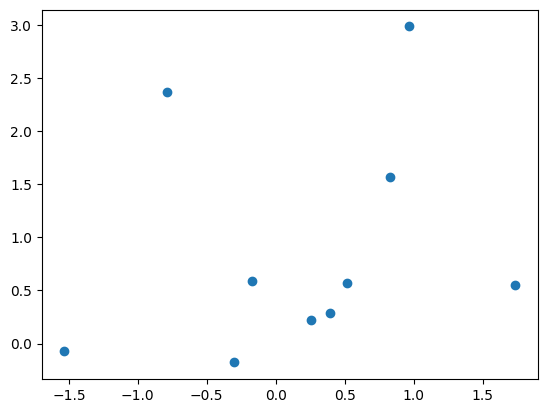

In [518]:
plt.scatter(x = z[0, :,0], y = z[0, :,1])

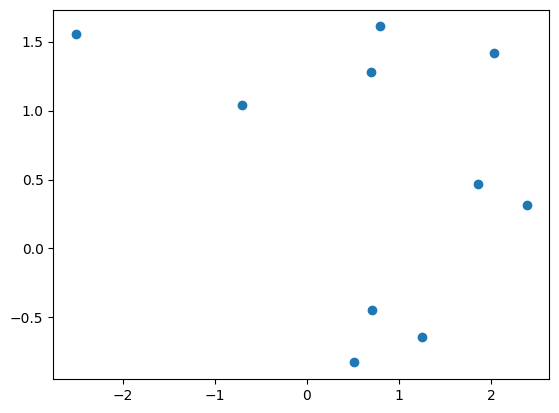

In [519]:
plt.scatter(x = z[99, :, 0], y = z[99, :, 1])

In [520]:
G[0]

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 0., 0., 1., 1.],
       [0., 0., 1., 1., 1., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 1.],
       [0., 1., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 1., 0., 1., 0., 0., 0., 1.],
       [1., 0., 1., 1., 0., 1., 1., 0., 0., 1.],
       [0., 1., 1., 0., 0., 0., 1., 0., 1., 0.],
       [0., 1., 1., 0., 1., 1., 0., 1., 1., 0.],
       [0., 1., 0., 0., 1., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 1., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0., 1., 0., 1., 0., 1.],
       [1., 1., 0., 1., 0., 0., 0., 0., 0., 0.]])

In [522]:
G[99]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])